Loading Data

**Course 6544 — Machine Learning & MLOps · Part 1: Data Engineering**


In [ ]:
import sys, subprocess
def pipq(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", *pkgs])

pipq("scikit-learn", "pandas", "numpy", "matplotlib", "seaborn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 60)
np.random.seed(0)
print("pandas", pd.__version__)

Matplotlib is building the font cache; this may take a moment.


## 1. Built-in sample datasets

> Add blockquote

[link text](https://)
scikit-learn ships small, clean datasets — perfect for trying an idea with zero cleaning.

feature matrix: (1797, 64) | target: (1797,)


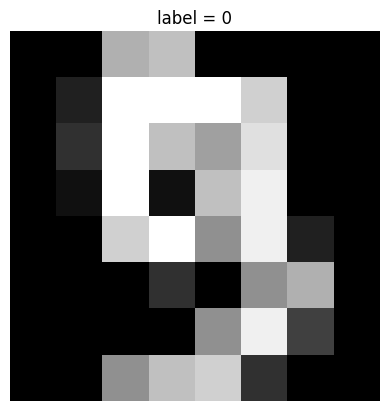

In [4]:
from sklearn import datasets
digits = datasets.load_digits()
X, y = digits.data, digits.target
print("feature matrix:", X.shape, "| target:", y.shape)
plt.imshow(digits.images[9], cmap="gray"); plt.title(f"label = {y[0]}"); plt.axis("off"); plt.show()

## 3. Load a CSV from a URL — Telco Customer Churn
A real telecom dataset: one row per customer, a `Churn` target.

In [6]:
TELCO_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(TELCO_URL)
print("shape:", df.shape)
df.head(3)

shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


**Pro tip.** `read_csv` has 30+ parameters. Useful ones: `sep` (delimiter), `header=None` (no header row), `na_values` (custom missing tokens), `nrows` (read a sample of a huge file).

In [7]:
print("columns:", list(df.columns))
print("\nTotalCharges dtype:", df["TotalCharges"].dtype,
      "<- stored as text! We fix this in notebook 02.")

columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

TotalCharges dtype: object <- stored as text! We fix this in notebook 02.


## 4. Excel, JSON, Parquet

> Add blockquote


Same shape of call. Here we write a small frame to each format, then read it back.

In [8]:
# Write the DataFrame to a JSON file (array of records)
df.to_json("telco_churn.json", orient="records", indent=2)
print("saved to telco_churn.json")

saved to telco_churn.json


## 5. Query a SQL database
Most enterprise data lives in databases. We build a throwaway SQLite DB and query it with SQL.

In [10]:
import sqlite3
conn = sqlite3.connect(":memory:")               # in-memory DB
df.to_sql("telco", conn, index=False, if_exists="replace")

q = "SELECT Contract, COUNT(*) AS n, AVG(MonthlyCharges) AS avg_charge " \
    "FROM telco GROUP BY Contract ORDER BY n DESC"
pd.read_sql_query(q, conn)

,Contract,n,avg_charge
0,Month-to-month,3875,66.398490
1,Two year,1695,60.770413
2,One year,1473,65.048608


## 6. Cloud sources (reference)
Google Sheets export as CSV from a URL; Amazon S3 uses `storage_options` with AWS keys. **Never hard-code credentials** — read them from environment variables or a git-ignored `.env`.

```python
sheet = pd.read_csv('https://docs.google.com/.../export?format=csv')
s3 = pd.read_csv('s3://bucket/data.csv',
                 storage_options={'key': KEY, 'secret': SECRET})
```